In [19]:
# Script1: Exploratory data analysis - Super-store-sales data
#Goal: Load the data, Understand it's shape, Check for issues

import pandas as pd
df = pd.read_csv("C:\\Users\\nazeer\\Desktop\\BI_Portfolio\\Sales-Analysis-Project\\Data\\Superstore.csv",encoding='latin-1')

In [20]:
# Print How many rows and columns?
print("Shape: " ,df.shape)

Shape:  (9994, 21)


In [21]:
#Column names
print("\ncolumns:\n",df.columns.tolist())


columns:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [22]:
#Data types and Null count
print("\nInfo:")
print(df.info)



Info:
<bound method DataFrame.info of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156  11-08-2016  11-11-2016    Second Class   
1          2  CA-2016-152156  11-08-2016  11-11-2016    Second Class   
2          3  CA-2016-138688  06-12-2016   6/16/2016    Second Class   
3          4  US-2015-108966  10-11-2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10-11-2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017  03-03-2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017  03-03-2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017  03-03-2017  Standard Class   
9993    9994  CA-2017-119914  05-04-2017  05-09-2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-1252

In [23]:
#Basic stats for numerical columns
print("\nSummary Stats: ")
print(df.describe())


Summary Stats: 
            Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55190.379428    229.858001     3.789574     0.156203   
std    2885.163629  32063.693350    623.245101     2.225110     0.206452   
min       1.000000   1040.000000      0.444000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  56430.500000     54.490000     3.000000     0.200000   
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000   
max    9994.000000  99301.000000  22638.480000    14.000000     0.800000   

            Profit  
count  9994.000000  
mean     28.656896  
std     234.260108  
min   -6599.978000  
25%       1.728750  
50%       8.666500  
75%      29.364000  
max    8399.976000  


In [24]:
#Check for the missing values
print("\nMissing Values: ")
print(df.isnull().sum())


Missing Values: 
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


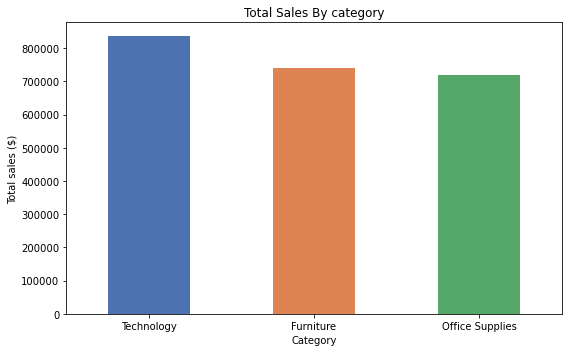

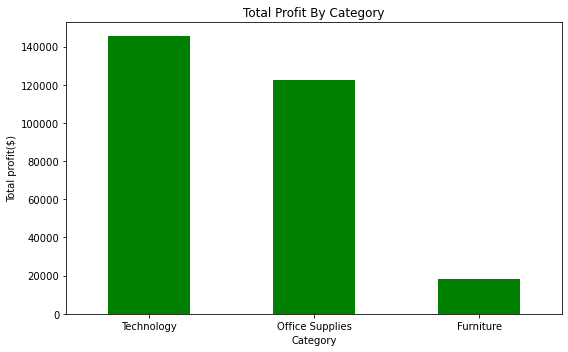

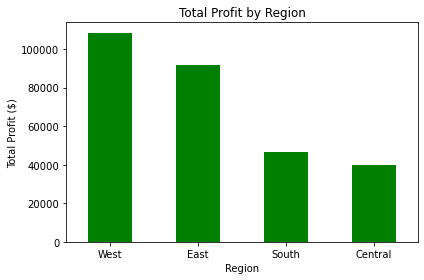

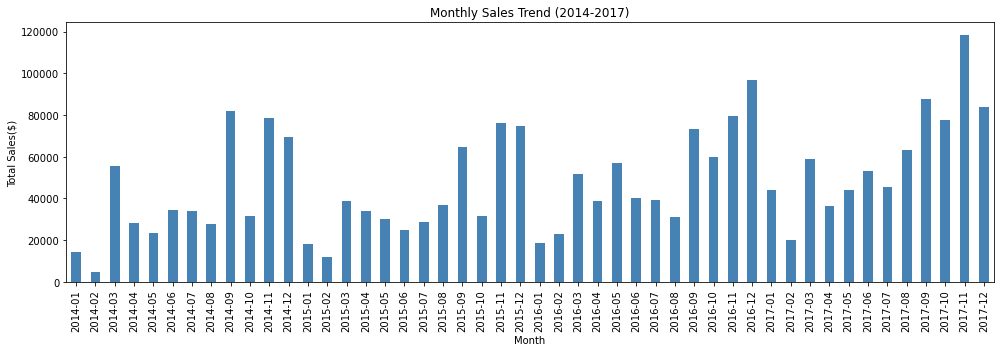

In [42]:
#Sales and profit Visulisations
#Goal is to create charts that shows key business insights

import pandas as pd
import matplotlib.pyplot as plt

# Chat-1 Total sales by Category 

sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))  #Set chart size
sales_by_category.plot(kind='bar',color= ['#4C72B0','#DD8452','#55A868']) 
plt.title("Total Sales By category")
plt.xlabel('Category')
plt.ylabel('Total sales ($)')
plt.xticks(rotation=0) #Keep lable Horizantal
plt.tight_layout()
plt.savefig('chart1_sales_by_category.png')
plt.show()


#--- Chart:2 Total Profit by Category --
Profit_by_Category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))  
colors = ['green' if p>0 else 'red' for p in Profit_by_Category]
sales_by_profit.plot(kind='bar',color=colors)
plt.title('Total Profit By Category')
plt.xlabel('Category')
plt.ylabel('Total profit($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('Chart2_Profit_by_Category')
plt.show()

# --- CHART 3: Profit by Region ---
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
colors = ['green' if p > 0 else 'red' for p in profit_by_region]
profit_by_region.plot(kind='bar', color=colors)
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart3_profit_by_region.png')
plt.show()

# --- CHART 4: Monthly Sales Trend ---

df['Order Date'] = pd.to_datetime(df['Order Date'])  # convert date column to proper date format
df['YearMonth'] = df['Order Date'].dt.to_period('M') # extract year-month (e.g. 2016-01)
monthly_sales = df.groupby('YearMonth')['Sales'].sum()

plt.figure(figsize=(14,5))
monthly_sales.plot(kind='bar',color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend (2014-2017)')
plt.xlabel('Month')
plt.ylabel('Total Sales($)')
plt.tight_layout()
plt.savefig('chart4_monthly_sales_trend')
plt.show()

In [49]:
# Script 3: Export Summary Tables as CSVs

import pandas as pd

df = pd.read_csv(r"C:\Users\nazeer\Desktop\BI_Portfolio\Sales-Analysis-Project\Data\Superstore.csv", encoding='latin-1')

# --- TABLE 1: Sales and Profit by Category ---
category_summary = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'count')
).round(2).sort_values('Total_Sales', ascending=False)

category_summary.to_csv('summary_by_category.csv')
print("Category Summary:")
print(category_summary)


# --- TABLE 2: Sales and Profit by Region ---
region_summary = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'count')
).round(2).sort_values('Total_Profit', ascending=False)

region_summary.to_csv('summary_by_region.csv')
print("\nRegion Summary:")
print(region_summary)

# --- TABLE 3: Profit by Sub-Category (sorted worst to best) ---
subcategory_summary = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).round(2).sort_values('Total_Profit', ascending=True)  # worst performers first

subcategory_summary.to_csv('summary_by_subcategory.csv')
print("\nSub-Category Summary (worst to best):")
print(subcategory_summary)

Category Summary:
                 Total_Sales  Total_Profit  Total_Orders
Category                                                
Technology         836154.03     145454.95          1847
Furniture          741999.80      18451.27          2121
Office Supplies    719047.03     122490.80          6026

Region Summary:
         Total_Sales  Total_Profit  Total_Orders
Region                                          
West       725457.82     108418.45          3203
East       678781.24      91522.78          2848
South      391721.90      46749.43          1620
Central    501239.89      39706.36          2323

Sub-Category Summary (worst to best):
              Total_Sales  Total_Profit
Sub-Category                           
Tables          206965.53     -17725.48
Bookcases       114880.00      -3472.56
Supplies         46673.54      -1189.10
Fasteners         3024.28        949.52
Machines        189238.63       3384.76
Labels           12486.31       5546.25
Art              27118.79  